In [1]:
import pandas as pd
import numpy as np

In [38]:
df = pd.read_csv("../data/raw/tourism_monthly_aggregated.csv")

df.head()

,Tabelle: 45412-0025
Arrivals,overnight stays in accommodation establishmen...
Länder,months;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;
Monthly tourism survey;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;,NaN
;;Baden-Württemberg;;;;Bayern;;;;Berlin;;;;Brandenburg;;;;Bremen;;;;Hamburg;;;;Hessen;;;;Mecklenburg-Vorpommern;;;;Niedersachsen;;;;Nordrhein-Westfalen;;;;Rheinland-Pfalz;;;;Saarland;;;;Sachsen;;;;Sachsen-Anhalt;;;;Schleswig-Holstein;;;;Thüringen;;;,NaN
;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;,NaN


In [39]:
# Read first few lines raw to inspect delimiter and structure
with open("../data/raw/tourism_monthly_aggregated.csv", "r", encoding="utf-8") as f:
    for i in range(10):
        print(f"{i}: {f.readline()}")

0: ﻿Tabelle: 45412-0025

1: Arrivals, overnight stays in accommodation establishments:;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

2: Länder, months;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

3: Monthly tourism survey;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;;

4: ;;Baden-Württemberg;;;;Bayern;;;;Berlin;;;;Brandenburg;;;;Bremen;;;;Hamburg;;;;Hessen;;;;Mecklenburg-Vorpommern;;;;Niedersachsen;;;;Nordrhein-Westfalen;;;;Rheinland-Pfalz;;;;Saarland;;;;Sachsen;;;;Sachsen-Anhalt;;;;Schleswig-Holstein;;;;Thüringen;;;

5: ;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;;Arrivals;;Overnight stays;

6: ;;number;number;number;number;number;num

### Step 1 – Read correctly with semicolon

In [40]:
# Read CSV with semicolon separator and skip metadata rows
df_raw = pd.read_csv(
    "../data/raw/tourism_monthly_aggregated.csv",
    sep=";",
    skiprows=7,   # Skip first 6 metadata lines (adjust if needed)
    header=None,
    encoding="utf-8"
)

df_raw.head(14)

,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,1992,January,600440.0,e,2217561.0,e,1065073.0,e,4259631.0,e,...,160887.0,e,121210.0,e,497031.0,e,82432.0,e,265369.0,e
1,NaN,February,721432.0,e,2463814.0,e,1352802.0,e,5134553.0,e,...,188368.0,e,156654.0,e,574781.0,e,107066.0,e,344474.0,e
2,NaN,March,813015.0,e,2788980.0,e,1360467.0,e,5150725.0,e,...,222624.0,e,222864.0,e,892871.0,e,112065.0,e,339572.0,e
3,NaN,April,973059.0,e,3363530.0,e,1563042.0,e,5647460.0,e,...,255319.0,e,381612.0,e,1884181.0,e,134258.0,e,398331.0,e
4,NaN,May,1229069.0,e,4079477.0,e,2021231.0,e,7078648.0,e,...,323241.0,e,509195.0,e,2451966.0,e,195720.0,e,556450.0,e
5,NaN,June,1247792.0,e,4342561.0,e,2126365.0,e,8375109.0,e,...,341470.0,e,616572.0,e,3314318.0,e,213746.0,e,606738.0,e
6,NaN,July,1338375.0,e,5144166.0,e,2435082.0,e,10593884.0,e,...,388839.0,e,783265.0,e,5083478.0,e,207882.0,e,704055.0,e
7,NaN,August,1375413.0,e,5472421.0,e,2365407.0,e,10951731.0,e,...,372253.0,e,683760.0,e,4660417.0,e,197944.0,e,682233.0,e
8,NaN,September,1330316.0,e,4636663.0,e,2268656.0,e,9117297.0,e,...,292476.0,e,478540.0,e,2749870.0,e,196921.0,e,553731.0,e
9,NaN,October,1173024.0,e,3922457.0,e,2002108.0,e,7246757.0,e,...,289761.0,e,390197.0,e,1884125.0,e,197582.0,e,543668.0,e


In [41]:
# Forward-fill the year column so each month gets the correct year
df_raw[0] = df_raw[0].ffill()

df_raw.head(14)

,0,1,2,3,4,5,6,7,8,9,...,56,57,58,59,60,61,62,63,64,65
0,1992,January,600440.0,e,2217561.0,e,1065073.0,e,4259631.0,e,...,160887.0,e,121210.0,e,497031.0,e,82432.0,e,265369.0,e
1,1992,February,721432.0,e,2463814.0,e,1352802.0,e,5134553.0,e,...,188368.0,e,156654.0,e,574781.0,e,107066.0,e,344474.0,e
2,1992,March,813015.0,e,2788980.0,e,1360467.0,e,5150725.0,e,...,222624.0,e,222864.0,e,892871.0,e,112065.0,e,339572.0,e
3,1992,April,973059.0,e,3363530.0,e,1563042.0,e,5647460.0,e,...,255319.0,e,381612.0,e,1884181.0,e,134258.0,e,398331.0,e
4,1992,May,1229069.0,e,4079477.0,e,2021231.0,e,7078648.0,e,...,323241.0,e,509195.0,e,2451966.0,e,195720.0,e,556450.0,e
5,1992,June,1247792.0,e,4342561.0,e,2126365.0,e,8375109.0,e,...,341470.0,e,616572.0,e,3314318.0,e,213746.0,e,606738.0,e
6,1992,July,1338375.0,e,5144166.0,e,2435082.0,e,10593884.0,e,...,388839.0,e,783265.0,e,5083478.0,e,207882.0,e,704055.0,e
7,1992,August,1375413.0,e,5472421.0,e,2365407.0,e,10951731.0,e,...,372253.0,e,683760.0,e,4660417.0,e,197944.0,e,682233.0,e
8,1992,September,1330316.0,e,4636663.0,e,2268656.0,e,9117297.0,e,...,292476.0,e,478540.0,e,2749870.0,e,196921.0,e,553731.0,e
9,1992,October,1173024.0,e,3922457.0,e,2002108.0,e,7246757.0,e,...,289761.0,e,390197.0,e,1884125.0,e,197582.0,e,543668.0,e


In [42]:
# Keep only value columns (drop flag columns)
# Column 0 = year
# Column 1 = month
# From column 2 onward: keep every second column (the numeric values)

cols_to_keep = [0, 1] + list(range(2, df_raw.shape[1], 2))

df_step1 = df_raw.iloc[:, cols_to_keep]

df_step1.head()

,0,1,2,4,6,8,10,12,14,16,...,46,48,50,52,54,56,58,60,62,64
0,1992,January,600440.0,2217561.0,1065073.0,4259631.0,186026.0,464027.0,51415.0,170000.0,...,32540.0,123004.0,119754.0,393632.0,46799.0,160887.0,121210.0,497031.0,82432.0,265369.0
1,1992,February,721432.0,2463814.0,1352802.0,5134553.0,199740.0,493109.0,58546.0,195291.0,...,36237.0,128024.0,146340.0,508719.0,55604.0,188368.0,156654.0,574781.0,107066.0,344474.0
2,1992,March,813015.0,2788980.0,1360467.0,5150725.0,264394.0,661653.0,79591.0,241490.0,...,45193.0,148085.0,164176.0,508403.0,71272.0,222624.0,222864.0,892871.0,112065.0,339572.0
3,1992,April,973059.0,3363530.0,1563042.0,5647460.0,273840.0,704231.0,96801.0,290799.0,...,45188.0,155201.0,192053.0,571987.0,85339.0,255319.0,381612.0,1884181.0,134258.0,398331.0
4,1992,May,1229069.0,4079477.0,2021231.0,7078648.0,326736.0,849169.0,161073.0,464512.0,...,55040.0,179997.0,254276.0,718866.0,112092.0,323241.0,509195.0,2451966.0,195720.0,556450.0


In [44]:
# Read only the line containing state names
with open("../data/raw/tourism_monthly_aggregated.csv", "r", encoding="utf-8") as f:
    lines = f.readlines()

state_line = lines[4]
print(state_line)

;;Baden-Württemberg;;;;Bayern;;;;Berlin;;;;Brandenburg;;;;Bremen;;;;Hamburg;;;;Hessen;;;;Mecklenburg-Vorpommern;;;;Niedersachsen;;;;Nordrhein-Westfalen;;;;Rheinland-Pfalz;;;;Saarland;;;;Sachsen;;;;Sachsen-Anhalt;;;;Schleswig-Holstein;;;;Thüringen;;;



In [45]:
# Split by semicolon
state_parts = state_line.strip().split(";")

state_parts[:20]  # inspect first elements


['',
 '',
 'Baden-Württemberg',
 '',
 '',
 '',
 'Bayern',
 '',
 '',
 '',
 'Berlin',
 '',
 '',
 '',
 'Brandenburg',
 '',
 '',
 '',
 'Bremen',
 '']

In [46]:
# Keep only non-empty entries
states = [s for s in state_parts if s != ""]

states

['Baden-Württemberg',
 'Bayern',
 'Berlin',
 'Brandenburg',
 'Bremen',
 'Hamburg',
 'Hessen',
 'Mecklenburg-Vorpommern',
 'Niedersachsen',
 'Nordrhein-Westfalen',
 'Rheinland-Pfalz',
 'Saarland',
 'Sachsen',
 'Sachsen-Anhalt',
 'Schleswig-Holstein',
 'Thüringen']

In [47]:
# Create new column names

new_columns = ["year", "month"]

for state in states:
    new_columns.append(f"{state}_arrivals")
    new_columns.append(f"{state}_overnight")

new_columns[:10]  # preview first few names

['year',
 'month',
 'Baden-Württemberg_arrivals',
 'Baden-Württemberg_overnight',
 'Bayern_arrivals',
 'Bayern_overnight',
 'Berlin_arrivals',
 'Berlin_overnight',
 'Brandenburg_arrivals',
 'Brandenburg_overnight']

In [48]:
# Assign new column names
df_step1.columns = new_columns

df_step1.head(14)

,year,month,Baden-Württemberg_arrivals,Baden-Württemberg_overnight,Bayern_arrivals,Bayern_overnight,Berlin_arrivals,Berlin_overnight,Brandenburg_arrivals,Brandenburg_overnight,...,Saarland_arrivals,Saarland_overnight,Sachsen_arrivals,Sachsen_overnight,Sachsen-Anhalt_arrivals,Sachsen-Anhalt_overnight,Schleswig-Holstein_arrivals,Schleswig-Holstein_overnight,Thüringen_arrivals,Thüringen_overnight
0,1992,January,600440.0,2217561.0,1065073.0,4259631.0,186026.0,464027.0,51415.0,170000.0,...,32540.0,123004.0,119754.0,393632.0,46799.0,160887.0,121210.0,497031.0,82432.0,265369.0
1,1992,February,721432.0,2463814.0,1352802.0,5134553.0,199740.0,493109.0,58546.0,195291.0,...,36237.0,128024.0,146340.0,508719.0,55604.0,188368.0,156654.0,574781.0,107066.0,344474.0
2,1992,March,813015.0,2788980.0,1360467.0,5150725.0,264394.0,661653.0,79591.0,241490.0,...,45193.0,148085.0,164176.0,508403.0,71272.0,222624.0,222864.0,892871.0,112065.0,339572.0
3,1992,April,973059.0,3363530.0,1563042.0,5647460.0,273840.0,704231.0,96801.0,290799.0,...,45188.0,155201.0,192053.0,571987.0,85339.0,255319.0,381612.0,1884181.0,134258.0,398331.0
4,1992,May,1229069.0,4079477.0,2021231.0,7078648.0,326736.0,849169.0,161073.0,464512.0,...,55040.0,179997.0,254276.0,718866.0,112092.0,323241.0,509195.0,2451966.0,195720.0,556450.0
5,1992,June,1247792.0,4342561.0,2126365.0,8375109.0,301829.0,766278.0,209099.0,598691.0,...,57833.0,185761.0,262353.0,768706.0,117586.0,341470.0,616572.0,3314318.0,213746.0,606738.0
6,1992,July,1338375.0,5144166.0,2435082.0,10593884.0,279331.0,681495.0,211419.0,828432.0,...,57933.0,217047.0,225695.0,820815.0,116899.0,388839.0,783265.0,5083478.0,207882.0,704055.0
7,1992,August,1375413.0,5472421.0,2365407.0,10951731.0,296693.0,721981.0,192712.0,667635.0,...,49679.0,209359.0,218937.0,725021.0,109141.0,372253.0,683760.0,4660417.0,197944.0,682233.0
8,1992,September,1330316.0,4636663.0,2268656.0,9117297.0,311098.0,769614.0,145490.0,424190.0,...,56562.0,180623.0,223267.0,642828.0,102218.0,292476.0,478540.0,2749870.0,196921.0,553731.0
9,1992,October,1173024.0,3922457.0,2002108.0,7246757.0,320114.0,773659.0,115111.0,338314.0,...,57531.0,180862.0,227798.0,649487.0,104831.0,289761.0,390197.0,1884125.0,197582.0,543668.0


In [49]:
# Create a proper datetime column from year and month
# Combine year and month into a single string like "1992 January"
df_step1["date"] = pd.to_datetime(
    df_step1["year"].astype(str) + " " + df_step1["month"],
    format="%Y %B"
)

# Move 'date' column to the first position
cols = df_step1.columns.tolist()
cols.remove("date")
cols = ["date"] + cols
df_step1 = df_step1[cols]

# Drop 'year' and 'month' columns since we now have a proper datetime column
df_step1 = df_step1.drop(columns=["year", "month"])

# Sort the dataframe by date to ensure chronological order
df_step1 = df_step1.sort_values("date").reset_index(drop=True)

# Preview the cleaned dataframe
df_step1.head()

/var/folders/2_/4gjpcdfn1xv5133yqx63q_wc0000gn/T/ipykernel_59534/3879161377.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_step1["date"] = pd.to_datetime(


,date,Baden-Württemberg_arrivals,Baden-Württemberg_overnight,Bayern_arrivals,Bayern_overnight,Berlin_arrivals,Berlin_overnight,Brandenburg_arrivals,Brandenburg_overnight,Bremen_arrivals,...,Saarland_arrivals,Saarland_overnight,Sachsen_arrivals,Sachsen_overnight,Sachsen-Anhalt_arrivals,Sachsen-Anhalt_overnight,Schleswig-Holstein_arrivals,Schleswig-Holstein_overnight,Thüringen_arrivals,Thüringen_overnight
0,1992-01-01,600440.0,2217561.0,1065073.0,4259631.0,186026.0,464027.0,51415.0,170000.0,34884.0,...,32540.0,123004.0,119754.0,393632.0,46799.0,160887.0,121210.0,497031.0,82432.0,265369.0
1,1992-02-01,721432.0,2463814.0,1352802.0,5134553.0,199740.0,493109.0,58546.0,195291.0,35181.0,...,36237.0,128024.0,146340.0,508719.0,55604.0,188368.0,156654.0,574781.0,107066.0,344474.0
2,1992-03-01,813015.0,2788980.0,1360467.0,5150725.0,264394.0,661653.0,79591.0,241490.0,40173.0,...,45193.0,148085.0,164176.0,508403.0,71272.0,222624.0,222864.0,892871.0,112065.0,339572.0
3,1992-04-01,973059.0,3363530.0,1563042.0,5647460.0,273840.0,704231.0,96801.0,290799.0,44781.0,...,45188.0,155201.0,192053.0,571987.0,85339.0,255319.0,381612.0,1884181.0,134258.0,398331.0
4,1992-05-01,1229069.0,4079477.0,2021231.0,7078648.0,326736.0,849169.0,161073.0,464512.0,54094.0,...,55040.0,179997.0,254276.0,718866.0,112092.0,323241.0,509195.0,2451966.0,195720.0,556450.0


In [50]:
df_step1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 412 entries, 0 to 411
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              408 non-null    datetime64[ns]
 1   Baden-Württemberg_arrivals        408 non-null    float64       
 2   Baden-Württemberg_overnight       408 non-null    float64       
 3   Bayern_arrivals                   408 non-null    float64       
 4   Bayern_overnight                  408 non-null    float64       
 5   Berlin_arrivals                   408 non-null    float64       
 6   Berlin_overnight                  408 non-null    float64       
 7   Brandenburg_arrivals              408 non-null    float64       
 8   Brandenburg_overnight             408 non-null    float64       
 9   Bremen_arrivals                   408 non-null    float64       
 10  Bremen_overnight                  408 non-null    

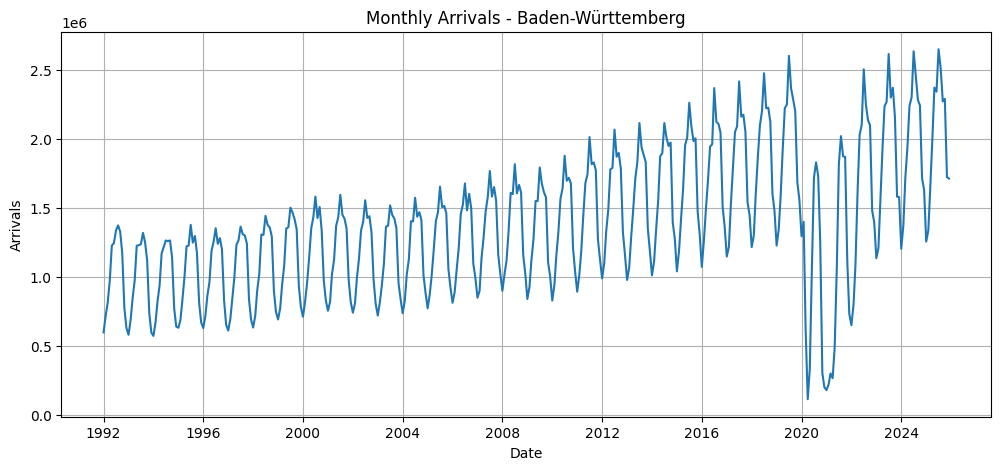

In [51]:
import matplotlib.pyplot as plt

# Plot Baden-Württemberg arrivals as a quick sanity check
plt.figure(figsize=(12, 5))

plt.plot(
    df_step1["date"],
    df_step1["Baden-Württemberg_arrivals"],
)

plt.title("Monthly Arrivals - Baden-Württemberg")
plt.xlabel("Date")
plt.ylabel("Arrivals")

plt.grid(True)
plt.show()

In [52]:
# Convert wide dataframe to long format
df_long = df_step1.melt(
    id_vars="date",
    var_name="state_metric",
    value_name="value"
)

# Split state and metric
df_long[["state", "metric"]] = df_long["state_metric"].str.rsplit(
    "_",
    n=1,
    expand=True
)

# Pivot to get arrivals and overnight as separate columns
df_long = df_long.pivot_table(
    index=["date", "state"],
    columns="metric",
    values="value"
).reset_index()

# Sort values for clean chronological order
df_long = df_long.sort_values(["state", "date"]).reset_index(drop=True)

# Preview result
df_long.head()

metric,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0


In [53]:
df_long.isna().sum()

metric
date         0
state        0
arrivals     0
overnight    0
dtype: int64

In [54]:
df_long[df_long["state"] == "Hamburg"].head()

metric,date,state,arrivals,overnight
2040,1992-01-01,Hamburg,137738.0,256550.0
2041,1992-02-01,Hamburg,154568.0,287609.0
2042,1992-03-01,Hamburg,180870.0,334884.0
2043,1992-04-01,Hamburg,179175.0,327863.0
2044,1992-05-01,Hamburg,210131.0,388591.0


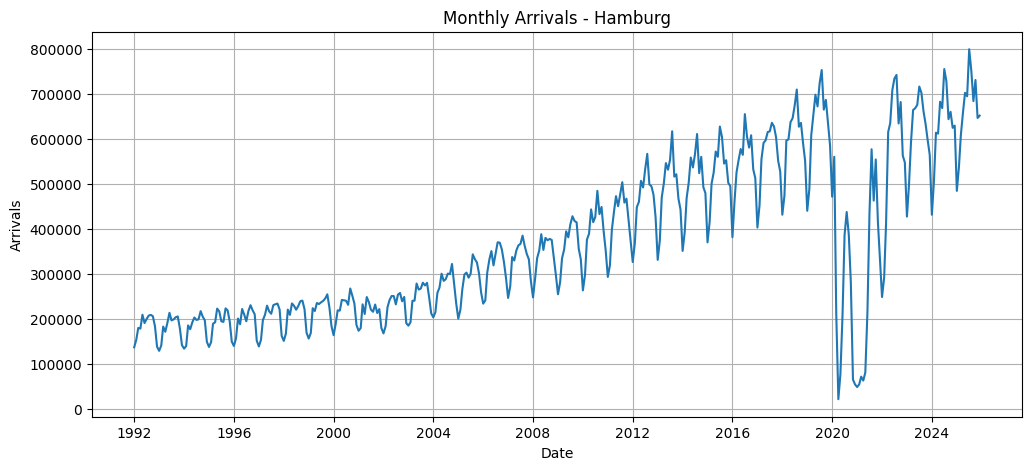

In [55]:
import matplotlib.pyplot as plt

# Filter dataframe for Hamburg only
hamburg_df = df_long[df_long["state"] == "Hamburg"]

# Plot Hamburg arrivals
plt.figure(figsize=(12, 5))

plt.plot(
    hamburg_df["date"],
    hamburg_df["arrivals"],
)

plt.title("Monthly Arrivals - Hamburg")
plt.xlabel("Date")
plt.ylabel("Arrivals")

plt.grid(True)
plt.show()

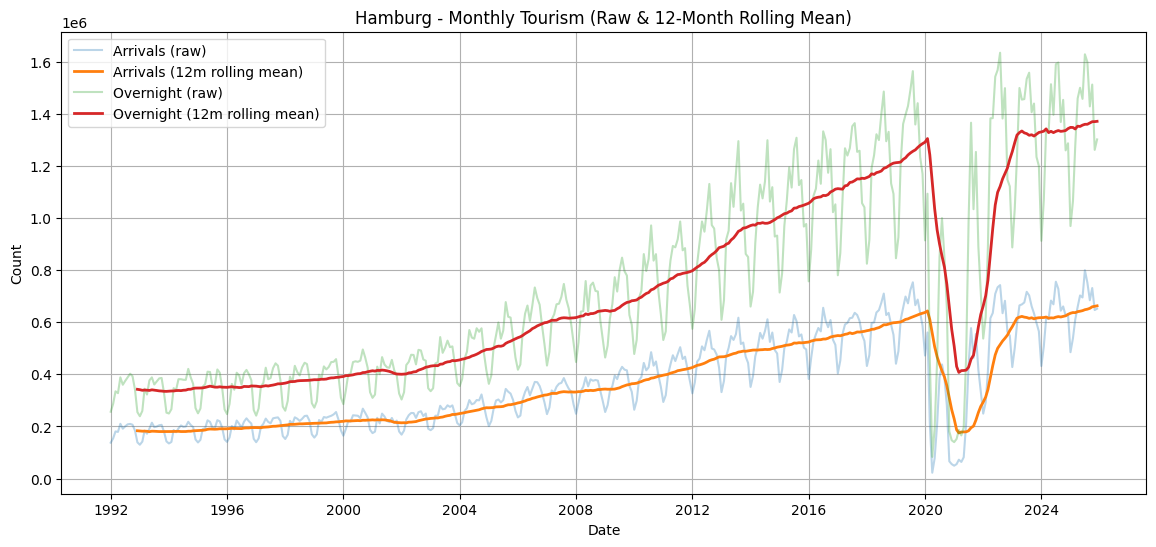

In [56]:
import matplotlib.pyplot as plt

# Filter dataframe for Hamburg only
hamburg_df = df_long[df_long["state"] == "Hamburg"].copy()

# Sort by date just to be safe
hamburg_df = hamburg_df.sort_values("date")

# Create 12-month rolling mean for smoother trend visualization
hamburg_df["arrivals_rolling_12m"] = hamburg_df["arrivals"].rolling(window=12).mean()
hamburg_df["overnight_rolling_12m"] = hamburg_df["overnight"].rolling(window=12).mean()

# Plot both raw values and rolling means
plt.figure(figsize=(14, 6))

# Raw arrivals
plt.plot(
    hamburg_df["date"],
    hamburg_df["arrivals"],
    alpha=0.3,
    label="Arrivals (raw)"
)

# Rolling arrivals
plt.plot(
    hamburg_df["date"],
    hamburg_df["arrivals_rolling_12m"],
    linewidth=2,
    label="Arrivals (12m rolling mean)"
)

# Raw overnight
plt.plot(
    hamburg_df["date"],
    hamburg_df["overnight"],
    alpha=0.3,
    label="Overnight (raw)"
)

# Rolling overnight
plt.plot(
    hamburg_df["date"],
    hamburg_df["overnight_rolling_12m"],
    linewidth=2,
    label="Overnight (12m rolling mean)"
)

plt.title("Hamburg - Monthly Tourism (Raw & 12-Month Rolling Mean)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.show()

In [57]:
# Save the cleaned and reshaped long dataframe as CSV
df_long.to_csv("../data/processed/tourism_long.csv", index=False)

print("File saved successfully.")

File saved successfully.


In [58]:
# Reload the saved CSV to ensure it works correctly
df_test = pd.read_csv("../data/processed/tourism_long.csv")

df_test.head()

,date,state,arrivals,overnight
0,1992-01-01,Baden-Württemberg,600440.0,2217561.0
1,1992-02-01,Baden-Württemberg,721432.0,2463814.0
2,1992-03-01,Baden-Württemberg,813015.0,2788980.0
3,1992-04-01,Baden-Württemberg,973059.0,3363530.0
4,1992-05-01,Baden-Württemberg,1229069.0,4079477.0
